# Waste Detection using Faster R-CNN

**Task:** find each waste item in an image, draw a box around it, and name its class.

**Pipeline:** Dataset (COCO format) -> Augmentation -> ResNet-50 backbone -> RPN (scout) -> Classifier + Box refiner (expert) -> NMS -> Final detections

**Steps in this notebook**
1. Install and import
2. Download dataset from Kaggle and set paths
3. Load data and split
4. Dataset class
5. Build model
6. Train and evaluate (mAP@0.5)
7. Plot results
8. Predict on images

## 1. Install and import

In [4]:
!pip install -q pycocotools kagglehub

In [5]:
import os
import random

import matplotlib.pyplot as plt
import torch
from PIL import Image, ImageDraw
from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval
from torch.utils.data import DataLoader, Dataset
from torchvision.models.detection import fasterrcnn_resnet50_fpn
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
import torchvision.transforms.functional as TF

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# fixed seeds so results are repeatable
random.seed(42)
torch.manual_seed(42)

Device: cuda


## 2. Download the dataset from Kaggle and set paths

Dataset: **TACO Trash Dataset** (`kneroma/tacotrashdataset`), COCO format, about 1500 images.
Link: https://www.kaggle.com/datasets/kneroma/tacotrashdataset

The code downloads it with `kagglehub` and finds `annotations.json` automatically.
Kaggle may ask for login. If it does, make a token at kaggle.com -> Settings -> Create New Token, then fill the two lines below.

In [6]:
# Only needed if the download asks you to log in:
# os.environ["KAGGLE_USERNAME"] = "your_kaggle_username"
# os.environ["KAGGLE_KEY"] = "your_kaggle_api_key"
# (or run: kagglehub.login())

import kagglehub

dataset_path = kagglehub.dataset_download("kneroma/tacotrashdataset")
print("Downloaded to:", dataset_path)

# find annotations.json anywhere inside the download
ANN_FILE, IMG_DIR = None, None
for root, _, files in os.walk(dataset_path):
    if "annotations.json" in files:
        ANN_FILE = os.path.join(root, "annotations.json")
        IMG_DIR = root          # image paths in the json are like batch_1/000006.jpg
        break

assert ANN_FILE is not None, "annotations.json not found inside the downloaded folder"
print("ANN_FILE:", ANN_FILE)
print("IMG_DIR :", IMG_DIR)

100%|██████████| 2.79G/2.79G [02:16<00:00, 22.0MB/s]

Extracting files...


Downloaded to: /root/.cache/kagglehub/datasets/kneroma/tacotrashdataset/versions/3
ANN_FILE: /root/.cache/kagglehub/datasets/kneroma/tacotrashdataset/versions/3/data/annotations.json
IMG_DIR : /root/.cache/kagglehub/datasets/kneroma/tacotrashdataset/versions/3/data


In [7]:
OUT_DIR = "outputs"

EPOCHS = 10
BATCH_SIZE = 2          # use 1 if you get out-of-memory errors
LR = 0.005
VAL_SPLIT = 0.2

os.makedirs(OUT_DIR, exist_ok=True)

## 3. Load data and split

Label 0 is always **background**, so waste classes start from 1.

In [8]:
GROUPS = {
    "Plastic": ["Carded blister pack", "Other plastic bottle", "Clear plastic bottle",
                "Plastic bottle cap", "Disposable plastic cup", "Other plastic cup",
                "Plastic lid", "Other plastic", "Plastic film", "Six pack rings",
                "Garbage bag", "Other plastic wrapper", "Single-use carrier bag",
                "Polypropylene bag", "Crisp packet", "Spread tub", "Tupperware",
                "Disposable food container", "Other plastic container", "Plastic glooves",
                "Plastic utensils", "Squeezable tube", "Plastic straw"],
    "Paper":   ["Toilet tube", "Other carton", "Egg carton", "Drink carton",
                "Corrugated carton", "Meal carton", "Pizza box", "Paper cup",
                "Magazine paper", "Tissues", "Wrapping paper", "Normal paper",
                "Paper bag", "Plastified paper bag", "Paper straw"],
    "Metal":   ["Aluminium foil", "Aluminium blister pack", "Food Can", "Aerosol",
                "Drink can", "Metal bottle cap", "Metal lid", "Pop tab", "Scrap metal"],
    "Glass":   ["Glass bottle", "Broken glass", "Glass cup", "Glass jar"],
    "Foam":    ["Foam cup", "Foam food container", "Styrofoam piece"],
    "Cigarette": ["Cigarette"],
    "Other":   ["Battery", "Food waste", "Shoe", "Unlabeled litter", "Rope & strings"],
}

coco = COCO(ANN_FILE)

# change every annotation's class to its group
name_to_group = {n: g for g, names in GROUPS.items() for n in names}
group_names = list(GROUPS.keys())
old_id_to_name = {c["id"]: c["name"] for c in coco.dataset["categories"]}
old_to_new = {oid: group_names.index(name_to_group.get(n, "Other")) + 1
              for oid, n in old_id_to_name.items()}

for ann in coco.dataset["annotations"]:
    ann["category_id"] = old_to_new[ann["category_id"]]
coco.dataset["categories"] = [{"id": i + 1, "name": g} for i, g in enumerate(group_names)]
coco.createIndex()

cat_ids = sorted(coco.getCatIds())
class_names = [coco.loadCats(c)[0]["name"] for c in cat_ids]
cat_to_label = {c: i + 1 for i, c in enumerate(cat_ids)}
label_to_cat = {v: k for k, v in cat_to_label.items()}
print(f"{len(class_names)} classes: {class_names}")

all_ids = sorted(coco.getImgIds())
random.shuffle(all_ids)
n_val = max(1, int(len(all_ids) * VAL_SPLIT))
val_ids, train_ids = all_ids[:n_val], all_ids[n_val:]
print("Total images:", len(all_ids))

first_file = coco.loadImgs(all_ids[0])[0]["file_name"]
assert os.path.exists(os.path.join(IMG_DIR, first_file)), f"Image not found: {first_file}"

loading annotations into memory...
Done (t=0.12s)
creating index...
index created!
creating index...
index created!
7 classes: ['Plastic', 'Paper', 'Metal', 'Glass', 'Foam', 'Cigarette', 'Other']
Total images: 1500


## 4. Dataset class

Reads each image and its boxes. COCO boxes are `[x, y, width, height]`, but Faster R-CNN needs `[x1, y1, x2, y2]`, so we convert them.

Augmentation (training only): random horizontal flip and brightness change.

In [9]:
from PIL import ImageOps
class WasteDataset(Dataset):
    def __init__(self, coco, img_dir, img_ids, cat_to_label, train=False):
        self.coco = coco
        self.img_dir = img_dir
        self.cat_to_label = cat_to_label
        self.train = train
        # keep only images that have at least one valid box
        self.ids = [i for i in img_ids if self._valid_anns(i)]

    def _valid_anns(self, img_id):
        anns = self.coco.loadAnns(self.coco.getAnnIds(imgIds=img_id, iscrowd=False))
        return [a for a in anns
                if a["bbox"][2] > 1 and a["bbox"][3] > 1
                and a["category_id"] in self.cat_to_label]

    def __len__(self):
        return len(self.ids)

    def __getitem__(self, idx):
        img_id = self.ids[idx]
        info = self.coco.loadImgs(img_id)[0]
        img = ImageOps.exif_transpose(Image.open(os.path.join(self.img_dir, info["file_name"]))).convert("RGB")
        w, h = img.size

        boxes, labels = [], []
        for a in self._valid_anns(img_id):
            x, y, bw, bh = a["bbox"]
            x1, y1 = max(0.0, x), max(0.0, y)
            x2, y2 = min(float(w), x + bw), min(float(h), y + bh)
            if x2 - x1 > 1 and y2 - y1 > 1:
                boxes.append([x1, y1, x2, y2])
                labels.append(self.cat_to_label[a["category_id"]])

        boxes = torch.tensor(boxes, dtype=torch.float32).reshape(-1, 4)
        labels = torch.tensor(labels, dtype=torch.int64)
        img = TF.to_tensor(img)

        if self.train:
            if random.random() < 0.5:
                img = TF.hflip(img)
                if len(boxes):
                    boxes[:, [0, 2]] = w - boxes[:, [2, 0]]
            img = TF.adjust_brightness(img, random.uniform(0.8, 1.2))

        target = {"boxes": boxes, "labels": labels, "image_id": img_id}
        return img, target


def collate_fn(batch):
    return tuple(zip(*batch))


train_ds = WasteDataset(coco, IMG_DIR, train_ids, cat_to_label, train=True)
val_ds = WasteDataset(coco, IMG_DIR, val_ids, cat_to_label, train=False)
print(f"Train images: {len(train_ds)} | Val images: {len(val_ds)}")
assert len(train_ds) > 0, "No usable training images. Check IMG_DIR and ANN_FILE."

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=2, collate_fn=collate_fn)
val_loader = DataLoader(val_ds, batch_size=1, shuffle=False,
                        num_workers=2, collate_fn=collate_fn)

Train images: 1200 | Val images: 300


### Quick look at one training image
Check that the boxes are placed correctly before training.

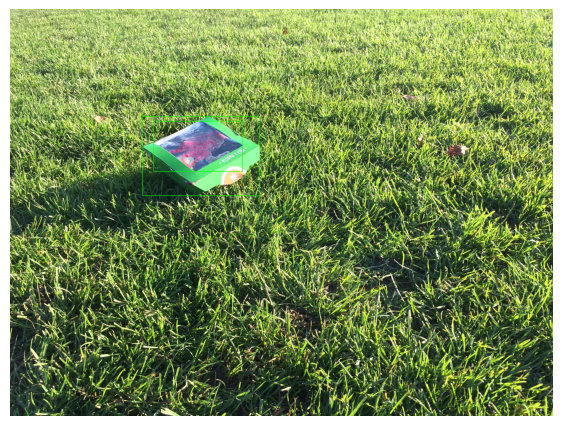

In [10]:
def show_sample(dataset, idx=0):
    img, target = dataset[idx]
    pil = TF.to_pil_image(img)
    draw = ImageDraw.Draw(pil)
    for box, lab in zip(target["boxes"].tolist(), target["labels"].tolist()):
        draw.rectangle(box, outline="lime", width=3)
        draw.text((box[0] + 3, max(0, box[1] - 12)), class_names[lab - 1], fill="lime")
    plt.figure(figsize=(7, 7))
    plt.imshow(pil)
    plt.axis("off")
    plt.show()

show_sample(train_ds, 0)

## 5. Build the model

- **Backbone:** ResNet-50 + FPN, pretrained on COCO (the eyes)
- **RPN:** suggests rough boxes (the scout)
- **Box head:** classifies each box and refines it (the expert)

We replace only the last layer so it predicts our waste classes. Classes + 1 because of background.

In [11]:
from torchvision.models.detection import fasterrcnn_resnet50_fpn_v2


def build_model(num_classes, pretrained=True):
    if pretrained:
        model = fasterrcnn_resnet50_fpn_v2(weights="DEFAULT", min_size=640, max_size=1000)
    else:
        model = fasterrcnn_resnet50_fpn_v2(weights=None, weights_backbone=None,
                                           min_size=640, max_size=1000)
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)
    return model


model = build_model(len(class_names) + 1).to(device)

params = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.SGD(params, lr=LR, momentum=0.9, weight_decay=0.0005)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.1)

Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_v2_coco-dd69338a.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_v2_coco-dd69338a.pth


100%|██████████| 167M/167M [00:01<00:00, 165MB/s]


## 6. Train and evaluate

- **Training loss** = classification loss + box regression loss (for both the scout and the expert).
- **mAP@0.5** = a prediction counts as correct only if IoU >= 0.5 and the class is right. It is scored over all images and classes.

In [12]:
use_amp = device.type == "cuda"
scaler = torch.amp.GradScaler("cuda", enabled=use_amp)
def train_one_epoch(model, loader, optimizer, device, epoch):
    model.train()
    total = 0.0
    for step, (images, targets) in enumerate(loader):
        images = [im.to(device) for im in images]
        targets = [{k: (v.to(device) if torch.is_tensor(v) else v) for k, v in t.items()}
                   for t in targets]

        with torch.autocast(device_type=device.type, enabled=use_amp):
          loss_dict = model(images, targets)
          loss = sum(loss_dict.values())

          optimizer.zero_grad()
          scaler.scale(loss).backward()
          scaler.step(optimizer)
          scaler.update()
        total += loss.item()
        if step % 20 == 0:
            print(f"  epoch {epoch} step {step}/{len(loader)} loss {loss.item():.4f}")
    return total / max(1, len(loader))


@torch.no_grad()
def evaluate(model, loader, coco, label_to_cat, device):
    model.eval()
    results, eval_ids = [], []
    for images, targets in loader:
        outputs = model([im.to(device) for im in images])
        for out, t in zip(outputs, targets):
            eval_ids.append(t["image_id"])
            for box, label, score in zip(out["boxes"].cpu().tolist(),
                                         out["labels"].cpu().tolist(),
                                         out["scores"].cpu().tolist()):
                x1, y1, x2, y2 = box
                results.append({
                    "image_id": t["image_id"],
                    "category_id": label_to_cat[label],
                    "bbox": [x1, y1, x2 - x1, y2 - y1],
                    "score": score,
                })
    if not results:
        print("  no detections yet -> mAP@0.5 = 0.0")
        return 0.0

    coco_dt = coco.loadRes(results)
    coco_eval = COCOeval(coco, coco_dt, "bbox")
    coco_eval.params.imgIds = eval_ids
    coco_eval.evaluate()
    coco_eval.accumulate()
    coco_eval.summarize()
    return float(coco_eval.stats[1])   # AP at IoU = 0.5

In [13]:
loss_history, map_history = [], []
best_map = -1.0

for epoch in range(1, EPOCHS + 1):
    loss = train_one_epoch(model, train_loader, optimizer, device, epoch)
    scheduler.step()

    map50 = evaluate(model, val_loader, coco, label_to_cat, device) if len(val_ds) else 0.0
    loss_history.append(loss)
    map_history.append(map50)
    print(f"Epoch {epoch}/{EPOCHS} | train loss {loss:.4f} | val mAP@0.5 {map50:.4f}")

    ckpt = {"model": model.state_dict(), "class_names": class_names}
    torch.save(ckpt, os.path.join(OUT_DIR, "last.pth"))
    if map50 >= best_map:
        best_map = map50
        torch.save(ckpt, os.path.join(OUT_DIR, "best.pth"))
        print("  saved best.pth")

print("Training done. Best mAP@0.5:", round(best_map, 4))

  epoch 1 step 0/600 loss 2.4782
  epoch 1 step 20/600 loss 1.2523
  epoch 1 step 40/600 loss 0.5827
  epoch 1 step 60/600 loss 0.3085
  epoch 1 step 80/600 loss 1.1432
  epoch 1 step 100/600 loss 0.5061
  epoch 1 step 120/600 loss 0.3278
  epoch 1 step 140/600 loss 0.4298
  epoch 1 step 160/600 loss 0.3315
  epoch 1 step 180/600 loss 1.0164
  epoch 1 step 200/600 loss 0.9327
  epoch 1 step 220/600 loss 0.3592
  epoch 1 step 240/600 loss 0.4513
  epoch 1 step 260/600 loss 0.3582
  epoch 1 step 280/600 loss 0.9051
  epoch 1 step 300/600 loss 0.8827
  epoch 1 step 320/600 loss 0.7308
  epoch 1 step 340/600 loss 0.7775
  epoch 1 step 360/600 loss 0.5975
  epoch 1 step 380/600 loss 0.3392
  epoch 1 step 400/600 loss 0.2033
  epoch 1 step 420/600 loss 0.2424
  epoch 1 step 440/600 loss 0.2978
  epoch 1 step 460/600 loss 1.1885
  epoch 1 step 480/600 loss 0.6623
  epoch 1 step 500/600 loss 0.7230
  epoch 1 step 520/600 loss 0.3810
  epoch 1 step 540/600 loss 0.3193
  epoch 1 step 560/600 los

## 7. Plot results

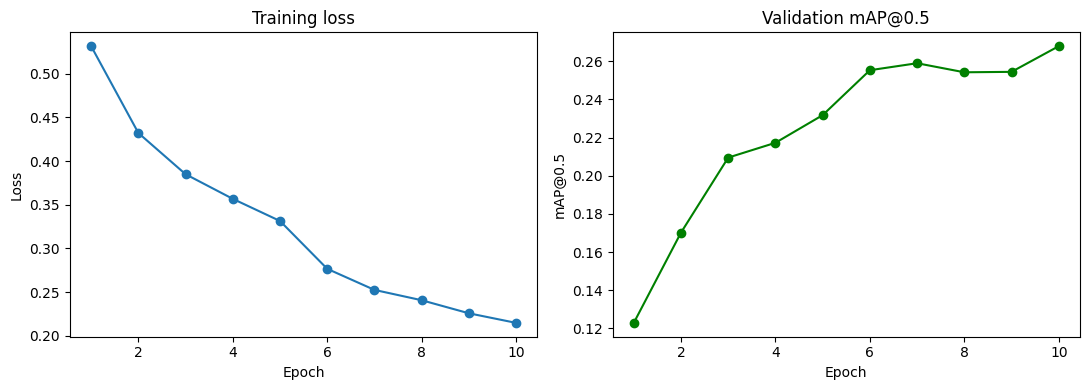

In [14]:
epochs_range = range(1, len(loss_history) + 1)

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(epochs_range, loss_history, marker="o")
ax[0].set_title("Training loss")
ax[0].set_xlabel("Epoch")
ax[0].set_ylabel("Loss")

ax[1].plot(epochs_range, map_history, marker="o", color="green")
ax[1].set_title("Validation mAP@0.5")
ax[1].set_xlabel("Epoch")
ax[1].set_ylabel("mAP@0.5")

plt.tight_layout()
plt.show()

## 8. Predict on images

Load the best saved weights, run the model, keep boxes above the confidence threshold, and draw them. NMS (duplicate box removal) is already applied inside the model.

ckpt = torch.load(os.path.join(OUT_DIR, "best.pth"), map_location=device)
class_names = ckpt["class_names"]

best_model = build_model(len(class_names) + 1, pretrained=False)
best_model.load_state_dict(ckpt["model"])
best_model.to(device).eval()


@torch.no_grad()
def predict(image_path, threshold=0.5, show=True):
    img = ImageOps.exif_transpose(Image.open(image_path)).convert("RGB")
    output = best_model([TF.to_tensor(img).to(device)])[0]

    keep = output["scores"] >= threshold
    boxes = output["boxes"][keep].cpu().tolist()
    labels = output["labels"][keep].cpu().tolist()
    scores = output["scores"][keep].cpu().tolist()

    draw = ImageDraw.Draw(img)
    for (x1, y1, x2, y2), lab, sc in zip(boxes, labels, scores):
        text = f"{class_names[lab - 1]} {sc:.2f}"
        draw.rectangle([x1, y1, x2, y2], outline="red", width=3)
        draw.text((x1 + 3, max(0, y1 - 12)), text, fill="red")
        print(text, [round(v) for v in (x1, y1, x2, y2)])

    print(f"Found {len(boxes)} object(s)")
    if show:
        plt.figure(figsize=(8, 8))
        plt.imshow(img)
        plt.axis("off")
        plt.show()
    return img

Plastic 0.96 [2084, 1086, 2405, 1383]
Plastic 0.87 [1792, 1289, 2112, 1551]
Cigarette 0.58 [841, 1628, 886, 1656]
Found 3 object(s)


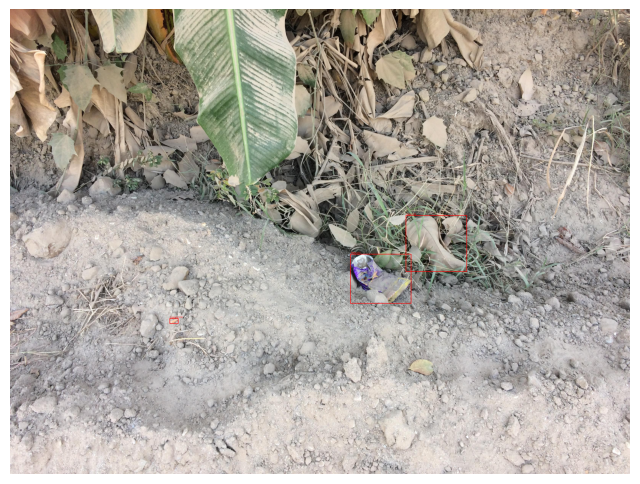

Plastic 1.00 [582, 1031, 2373, 2961]
Found 1 object(s)


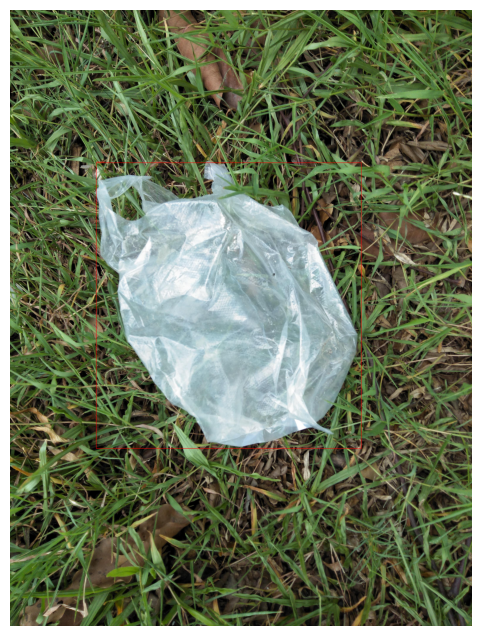

Plastic 1.00 [1617, 2395, 1859, 2761]
Plastic 0.99 [1931, 3249, 2373, 3813]
Plastic 0.94 [1721, 1739, 1953, 2045]
Plastic 0.89 [3, 3437, 221, 4012]
Plastic 0.52 [574, 1374, 751, 1469]
Found 5 object(s)


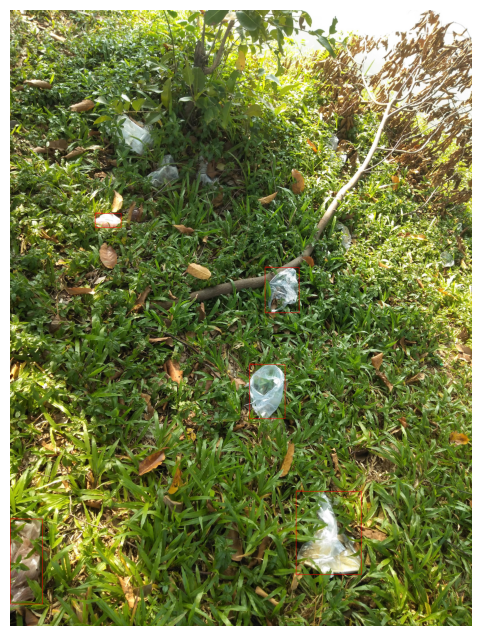

In [16]:
# Try a few validation images
for i in range(min(3, len(val_ds))):
    info = coco.loadImgs(val_ds.ids[i])[0]
    predict(os.path.join(IMG_DIR, info["file_name"]), threshold=0.5)